In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import inspect
import json
import types
from torch import Tensor
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

In [2]:
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti


### Downlaoding and Processing CIFAR-10 

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)

## Task 1.1: Baseline Setup

In [5]:
model = models.resnet152(weights="DEFAULT")
# Freezing the paramters so they won't get updated during backward pass
for param in model.parameters():
    param.requires_grad = False

# Modifying the final fully connected layer in ResNet
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:03<00:00, 69.5MB/s] 


In [7]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/20 | Train Loss: 0.6160, Train Acc: 0.8055 | Val Loss: 0.5124, Val Acc: 0.8303
Epoch 2/20 | Train Loss: 0.4800, Train Acc: 0.8407 | Val Loss: 0.4705, Val Acc: 0.8437
Epoch 3/20 | Train Loss: 0.4509, Train Acc: 0.8477 | Val Loss: 0.4576, Val Acc: 0.8505
Epoch 4/20 | Train Loss: 0.4242, Train Acc: 0.8581 | Val Loss: 0.4596, Val Acc: 0.8483
Epoch 5/20 | Train Loss: 0.4039, Train Acc: 0.8635 | Val Loss: 0.4526, Val Acc: 0.8499
Epoch 6/20 | Train Loss: 0.3905, Train Acc: 0.8671 | Val Loss: 0.4495, Val Acc: 0.8478
Epoch 7/20 | Train Loss: 0.3825, Train Acc: 0.8697 | Val Loss: 0.4549, Val Acc: 0.8475
Epoch 8/20 | Train Loss: 0.3719, Train Acc: 0.8734 | Val Loss: 0.4547, Val Acc: 0.8490
Epoch 9/20 | Train Loss: 0.3729, Train Acc: 0.8724 | Val Loss: 0.4578, Val Acc: 0.8475
Epoch 10/20 | Train Loss: 0.3624, Train Acc: 0.8764 | Val Loss: 0.4711, Val Acc: 0.8431
Epoch 11/20 | Train Loss: 0.3599, Train Acc: 0.8754 | Val Loss: 0.4493, Val Acc: 0.8511
Epoch 12/20 | Train Loss: 0.3577, Train A

In [2]:
history = {
    "train_loss": [0.6160, 0.4800, 0.4509, 0.4242, 0.4039, 0.3905, 0.3825, 0.3719, 0.3729, 0.3624,
                   0.3599, 0.3577, 0.3546, 0.3478, 0.3461, 0.3420, 0.3437, 0.3419, 0.3376, 0.3407],

    "train_acc": [0.8055, 0.8407, 0.8477, 0.8581, 0.8635, 0.8671, 0.8697, 0.8734, 0.8724, 0.8764,
                  0.8754, 0.8747, 0.8768, 0.8808, 0.8812, 0.8824, 0.8800, 0.8807, 0.8827, 0.8809],

    "val_loss": [0.5124, 0.4705, 0.4576, 0.4596, 0.4526, 0.4495, 0.4549, 0.4547, 0.4578, 0.4711,
                 0.4493, 0.4606, 0.4740, 0.4688, 0.4655, 0.4722, 0.4759, 0.4813, 0.4701, 0.4823],

    "val_acc": [0.8303, 0.8437, 0.8505, 0.8483, 0.8499, 0.8478, 0.8475, 0.8490, 0.8475, 0.8431,
                0.8511, 0.8460, 0.8405, 0.8425, 0.8485, 0.8452, 0.8448, 0.8423, 0.8471, 0.8457]
}

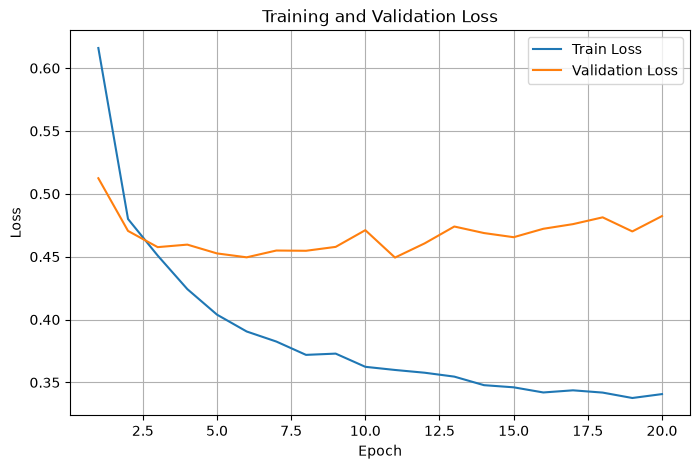

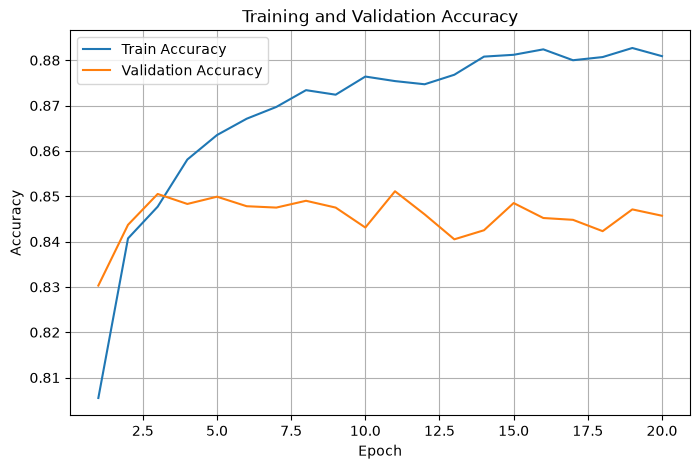

In [3]:
epochs = range(1, 21)

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Task 1.2: Residual Connections in Practice

In [6]:
def forward_skip(self, x: Tensor):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    out = self.relu(out)

    return out

    
model = models.resnet152(weights="DEFAULT")

model.layer1[0].forward = types.MethodType(forward_skip, model.layer1[0])
model.layer2[1].forward = types.MethodType(forward_skip, model.layer2[1])
model.layer3[1].forward = types.MethodType(forward_skip, model.layer3[1])
model.layer4[0].forward = types.MethodType(forward_skip, model.layer4[0])

# Freezing the paramters so they won't get updated during backward pass
for param in model.parameters():
    param.requires_grad = False

# print(model)

print(inspect.getsource(model.layer1[0].forward))


# Modifying the final fully connected layer in ResNet
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)


Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:02<00:00, 89.2MB/s] 


def forward_skip(self, x: Tensor):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    out = self.relu(out)

    return out



Epoch 1/20 | Train Loss: 2.2907, Train Acc: 0.1279 | Val Loss: 2.6147, Val Acc: 0.1437
Epoch 2/20 | Train Loss: 2.2753, Train Acc: 0.1454 | Val Loss: 2.7758, Val Acc: 0.1369
Epoch 3/20 | Train Loss: 2.2698, Train Acc: 0.1447 | Val Loss: 2.5990, Val Acc: 0.1548
Epoch 4/20 | Train Loss: 2.2641, Train Acc: 0.1483 | Val Loss: 2.5829, Val Acc: 0.1555
Epoch 5/20 | Train Loss: 2.2622, Train Acc: 0.1503 | Val Loss: 2.4518, Val Acc: 0.1535
Epoch 6/20 | Train Loss: 2.2592, Train Acc: 0.1522 | Val Loss: 2.6851, Val Acc: 0.1524
Epoch 7/20 | Train Loss: 2.2586, Train Acc: 0.1530 | Val Loss: 2.7969, Val Acc: 0.1541
Epoch 8/20 | Train Loss: 2.2574, Train Acc: 0.1555 | Val Loss: 3.8217, Val Acc: 0.1551
Epoch 9/20 | Train Loss: 2.2565, Train Acc: 0.1551 | Val Loss: 2.6153, Val Acc: 0.1625
Epoch 10/20 | Train Loss: 2.2530, Train Acc: 0.1553 | Val Loss: 3.3295, Val Acc: 0.1578
Epoch 11/20 | Train Loss: 2.2549, Train Acc: 0.1557 | Val Loss: 2.5748, Val Acc: 0.1582
Epoch 12/20 | Train Loss: 2.2524, Train A

ValueError: x and y must have same first dimension, but have shapes (20,) and (1,)

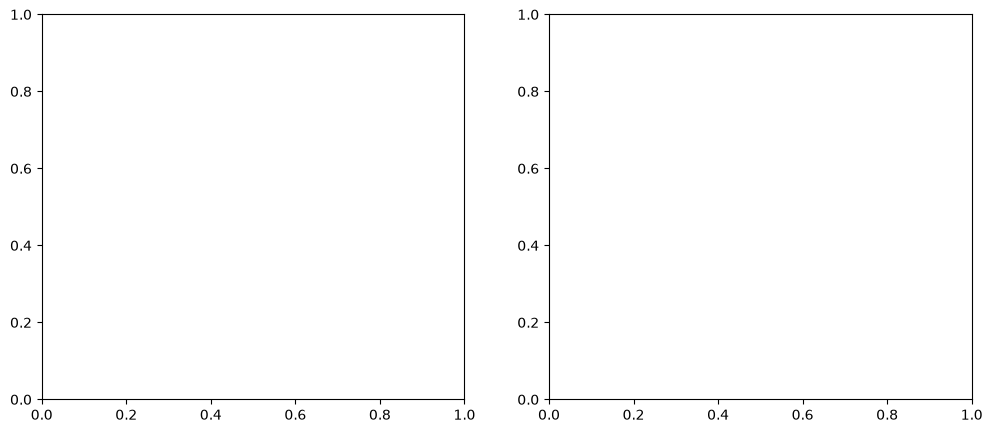

In [7]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


with open("history_task1_2.json", "w") as f:
    json.dump(history, f)

epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss per Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy per Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

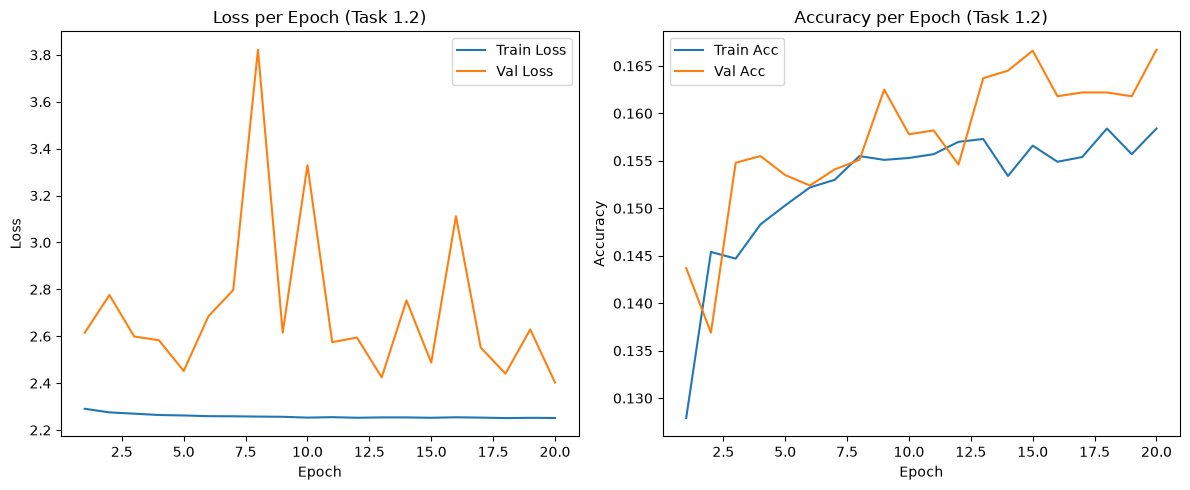

In [8]:
history = {
    "train_loss": [2.2907, 2.2753, 2.2698, 2.2641, 2.2622, 2.2592, 2.2586, 2.2574, 2.2565, 2.2530,
                    2.2549, 2.2524, 2.2539, 2.2539, 2.2523, 2.2544, 2.2530, 2.2510, 2.2521, 2.2515],
    "train_acc":  [0.1279, 0.1454, 0.1447, 0.1483, 0.1503, 0.1522, 0.1530, 0.1555, 0.1551, 0.1553,
                    0.1557, 0.1570, 0.1573, 0.1534, 0.1566, 0.1549, 0.1554, 0.1584, 0.1557, 0.1584],
    "val_loss":   [2.6147, 2.7758, 2.5990, 2.5829, 2.4518, 2.6851, 2.7969, 3.8217, 2.6153, 3.3295,
                    2.5748, 2.5944, 2.4246, 2.7530, 2.4876, 3.1122, 2.5517, 2.4403, 2.6290, 2.4029],
    "val_acc":    [0.1437, 0.1369, 0.1548, 0.1555, 0.1535, 0.1524, 0.1541, 0.1551, 0.1625, 0.1578,
                    0.1582, 0.1546, 0.1637, 0.1645, 0.1666, 0.1618, 0.1622, 0.1622, 0.1618, 0.1667],
}

num_epochs = 20
epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss per Epoch (Task 1.2)")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy per Epoch (Task 1.2)")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/loss_accuracy_task1_2.png", dpi=150)
plt.show()